# Práctica 3

Importamos las librerías que vamos a usar:

In [66]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from numpy import pi, random
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.result import marginal_counts
import numpy as np
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate

## Ejercicio 1: "Codifica una función llamada teleportacion"

Preparamos las funciones que usaremos para teleportación:

In [17]:
def crear_estado_bell(circ, b, c, b_s):#|cb>/|q2q1>

    ##Se eligirá el circuito necesario para crear el estado de bell deseado 
    match b_s:
        case 0:
            ##CNOT(HxI)|00>:
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 1:   
            ##CNOT(HxI)|01>:
            circ.x(b)
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 2:
            ##CNOT(HxI)|10>:
            circ.x(c)
            circ.h(c)       # poner el qubit c en el estado |->
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case 3:
            
            ##CNOT(HxI)|11>:
            circ.x(c)
            circ.x(b)
            circ.h(c)       # poner el qubit c en el estado |->
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
        case _:
            ##CNOT(HxI)|00>:
            circ.h(c)       # poner el qubit c en el estado |+>
            circ.cx(c, b)   # CNOT con control el qubit c y objetivo el qubit b
            
def compuertas_alicia(circ, psi, a): #Procedimiento que hace alicia para enviar sus qbits
    circ.barrier()
    circ.cx(psi, a)
    circ.h(psi)

def mediciones_y_envio(circ, psi, a): 
    circ.barrier()
    circ.measure(psi, 0)
    circ.measure(a, 1)

def decodificacion_bob(circ,b_s):
    match b_s: #Decodificación segun estado entrelazado de bell usado
        case 0:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
           
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')

        case 1:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.x(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')

        case 2:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.z(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')
        case 3:
                
            # Bob decodifica su qubit 
            circ.cz(qr_alicia[0], qr_bob[0])   
            circ.cx(qr_alicia[1], qr_bob)
            circ.x(qr_bob[0])
            circ.z(qr_bob[0])
            
            
            # Finalmente, medir el qubit de Bob (en otro cbit)
            circ.barrier()
            bob_med = ClassicalRegister(1, name="bob_med")
            circ.add_register(bob_med)
            circ.measure(qr_bob[0], bob_med)
            
            circ.draw('mpl')


Definimos la función teleportación:

In [3]:
def teleportacion(circ,bell_state):
    
    crear_estado_bell(circ, 1, 2, bell_state)   # circuito, índice qubit b, índice qubit c, estado de bell deseado
    compuertas_alicia(circ, 0, 1)
    mediciones_y_envio(circ, 0, 1)
    decodificacion_bob(circ,bell_state)

Preparamos un estado aleatorio: 

<IPython.core.display.Latex object>

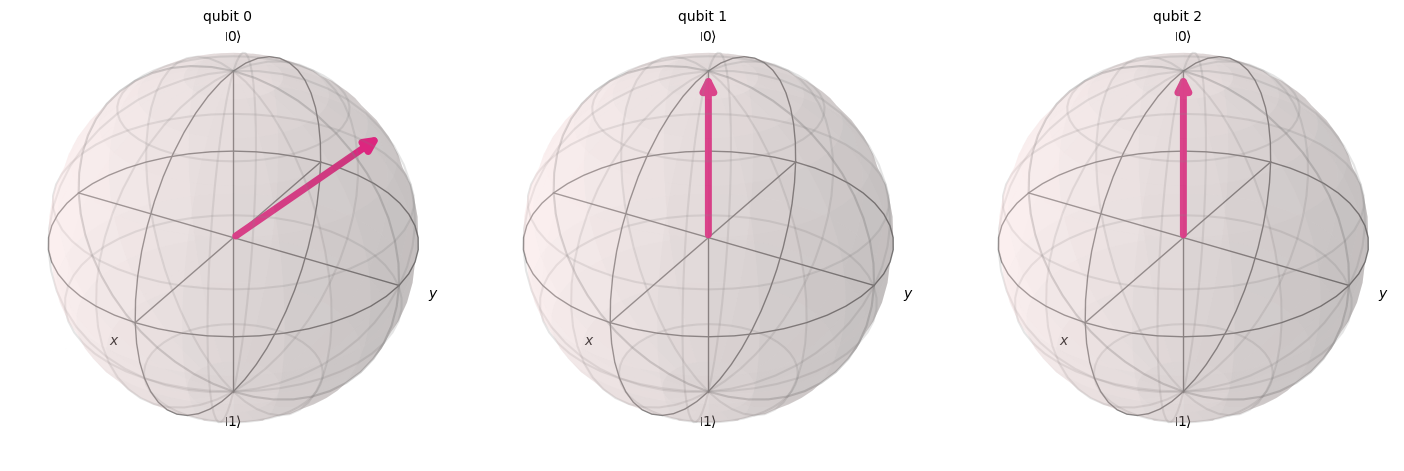

In [6]:
# generamos 3 ángulos al azar, para posicionarnos en la esfera de Bloch en una posición aleatoria
theta = random.random() * 2 * pi
phi = random.random() * 2 * pi
lam = random.random() * 2 * pi


qr_alicia = QuantumRegister(2, name='alicia')  # dos qubits de Alicia
qr_bob = QuantumRegister(1, name='bob')        # un qubit de Bob
crz = ClassicalRegister(1, name='crz')         # 2 bits clasicos
crx = ClassicalRegister(1, name='crx')         # en 2 diferentes registros

circuitoTest0= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest1= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest2= QuantumCircuit(qr_alicia, qr_bob, crz, crx)
circuitoTest3= QuantumCircuit(qr_alicia, qr_bob, crz, crx)


circuitoTest0.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest1.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest2.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios
circuitoTest3.u(theta, phi, lam, [qr_alicia[0]])   # rotar el qubit 0 de alicia con los ángulos aleatorios

psi_state = Statevector(circuitoTest1)                             # obtenemos el vector de estado para visualizarlo

display(psi_state.draw('latex', prefix="|\\psi\\rangle ="))    # mostrar en notación de Dirac

plot_bloch_multivector(psi_state)                              # mostrar en esfera de Bloch

    

Ahora aplicaremos el circuito pasando como estado entrelazado cada estado de bell:

### Para el estado entrelazado de Bell $\lvert \Phi^+ \rangle = \frac{1}{\sqrt{2}} \left( \lvert 00 \rangle + \lvert 11 \rangle \right)$

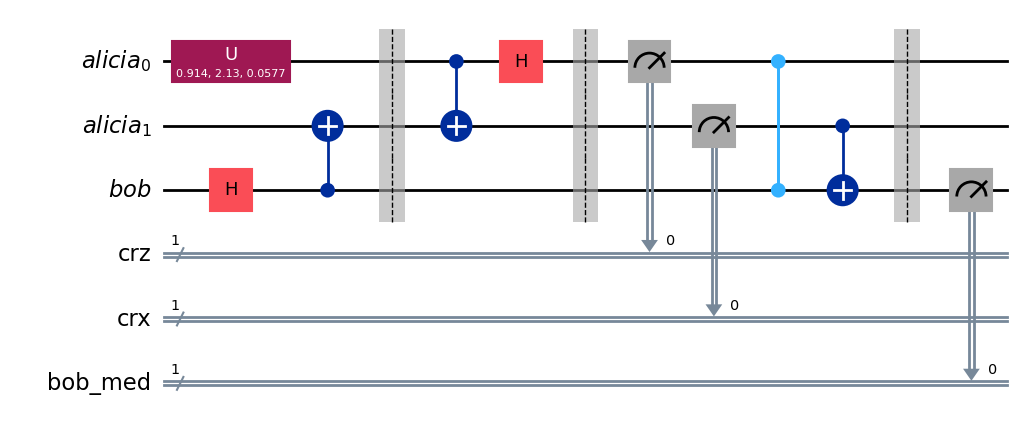

In [7]:

teleportacion(circuitoTest0,0)
circuitoTest0.draw('mpl')


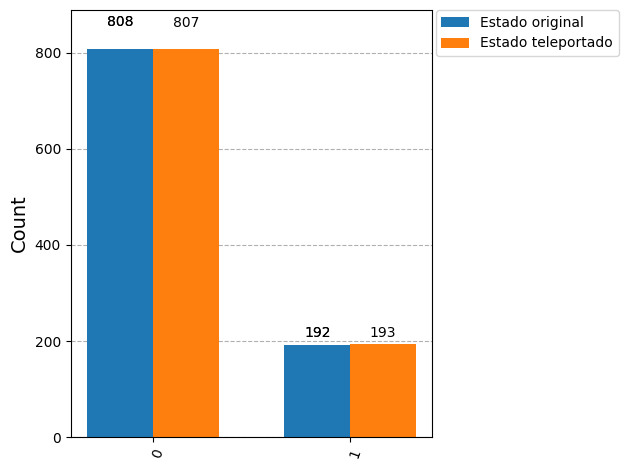

In [8]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest0,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

### Para el estado entrelazado de Bell $\left|\Psi^+\right\rangle=\frac{1}{\sqrt{2}}(\lvert 01\rangle+\lvert 10\rangle)$

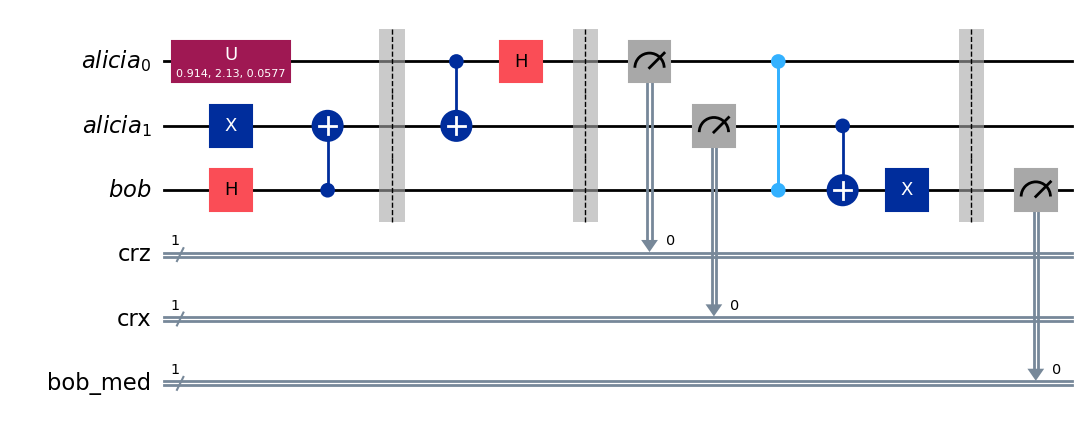

In [9]:
teleportacion(circuitoTest1,1)
circuitoTest1.draw('mpl')


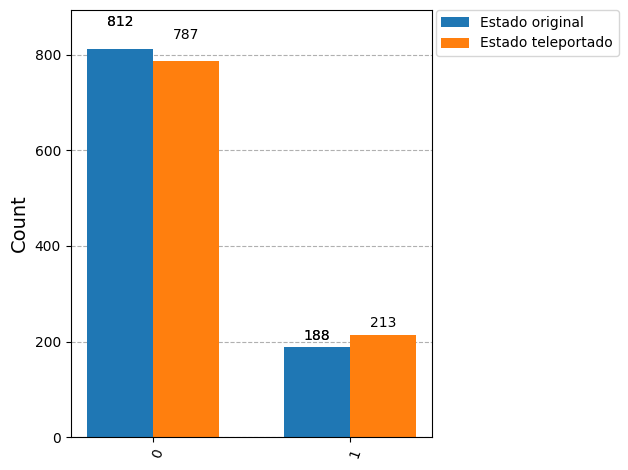

In [10]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest1,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

### Para el estado entrelazado de Bell $\lvert \Phi^- \rangle = \frac{1}{\sqrt{2}} \left( \lvert 00 \rangle - \lvert 11 \rangle \right)$

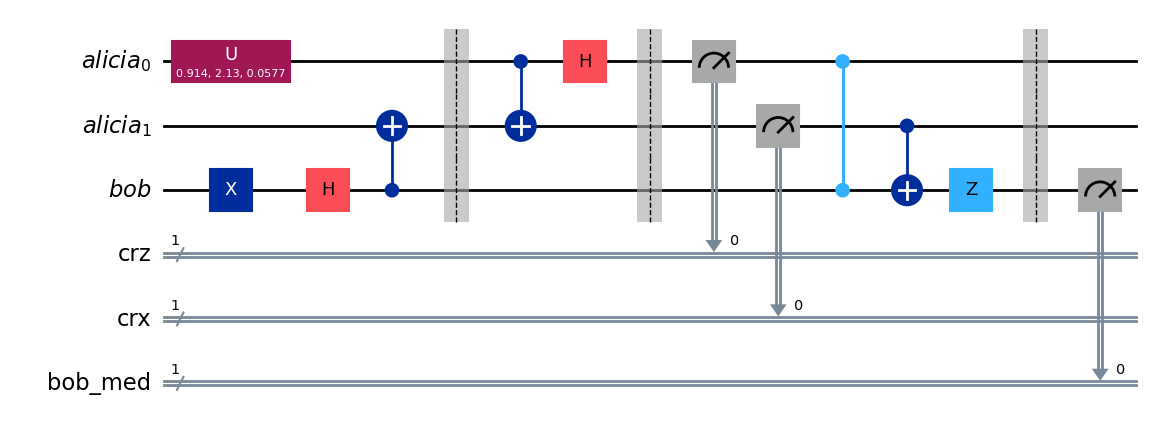

In [11]:
teleportacion(circuitoTest2,2)
circuitoTest2.draw('mpl')


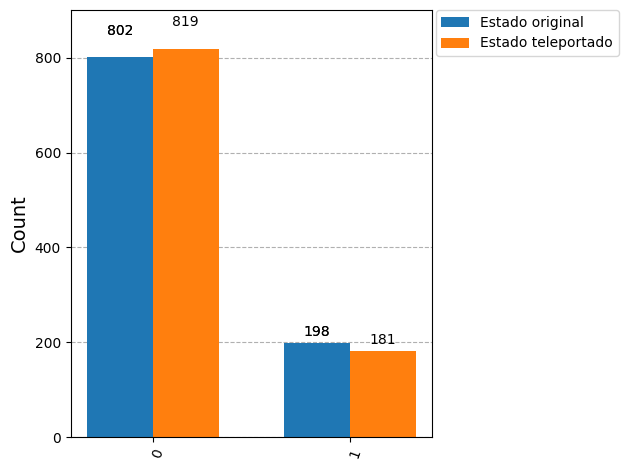

In [12]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest2,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

### Para el estado entrelazado de Bell $\left|\Psi^-\right\rangle=\frac{1}{\sqrt{2}}(\lvert 01\rangle-\lvert 10\rangle)$

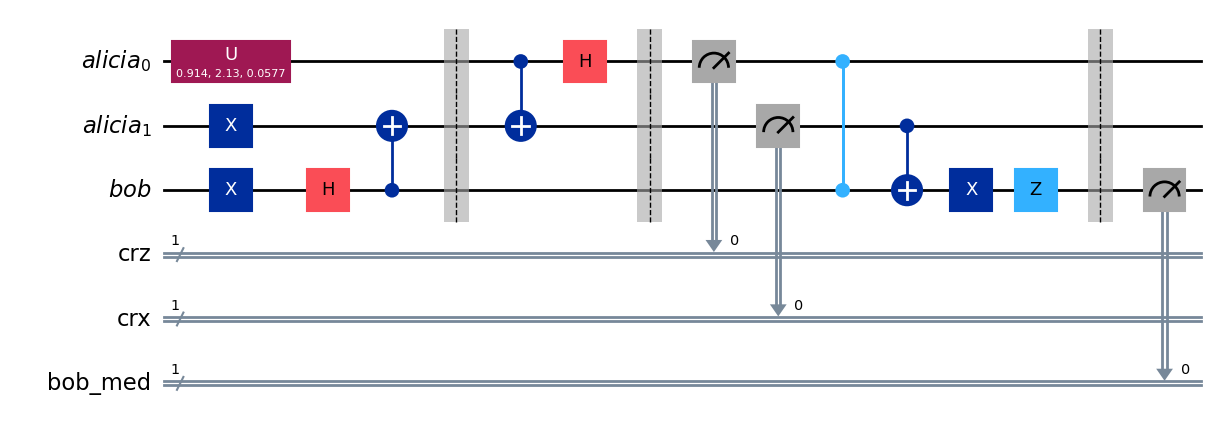

In [13]:
teleportacion(circuitoTest3,3)
circuitoTest3.draw('mpl')


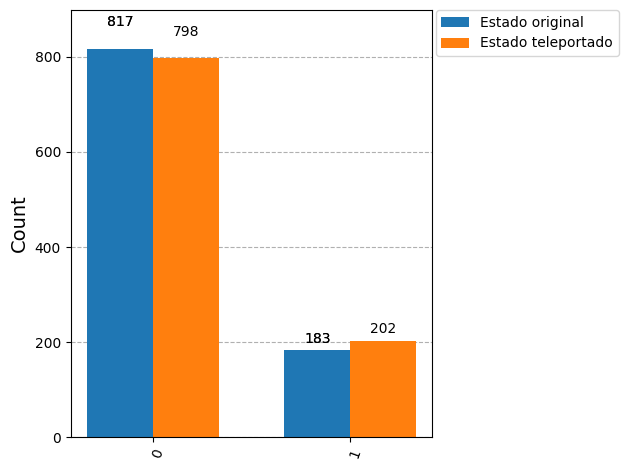

In [14]:
sim_basic = BasicSimulator()                                  # usamos el simulador básico

# otro circuito con solo el estado a enviar 'psi', para simularlo y poder compararlo al final
cirq_estado_enviar = QuantumCircuit(1, 1)
cirq_estado_enviar.u(theta, phi, lam, 0)
cirq_estado_enviar.measure(0, 0)

job_inicializacion = sim_basic.run(cirq_estado_enviar,shots=1000)        # simulamos el circuito con solo el estado a enviar

job_teleportacion = sim_basic.run(circuitoTest3,shots=1000)     # simulamos el circuito de teleportación


# marginar conteos, es decir, solo quedarnos con los del cbit que contiene la medición de Bob
conteos = job_teleportacion.result().get_counts()
tele_counts = marginal_counts(conteos, [2])                  # solo nos interesan los resultados del qubit de Bob, que es el de índice 2


# graficamos los resultados con un histograma

legend = ["Estado original", "Estado teleportado"]
plot_histogram([job_inicializacion.result().get_counts(), tele_counts], legend=legend)

## Ejercicio 2: "Implementa las funciones cuánticas And y Or"

### AND

La tabla de verdad del circuito es:

$$
\begin{array}{|c|c|c|}
\hline
X0 & X1 & f = X0 \land X1 \\
\hline
0 & 0 & 0 \\
0 & 1 & 0 \\
1 & 0 & 0 \\
1 & 1 & 1 \\
\hline
\end{array}
$$


Por lo que el circuito a implementar es el siguiente

In [67]:
def quantumAnd(circ): ##La función And 
    circ.ccx(0,1,2)
    return circ


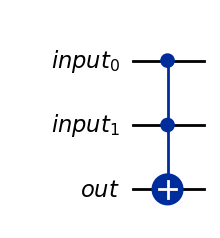

In [68]:
qr_in = QuantumRegister(2, name='input')  # dos qubits de entrada
qr_out = QuantumRegister(1, name='out')        # un qubit de salida

circuitoAnd = quantumAnd(QuantumCircuit(qr_in, qr_out))

circuitoAnd.draw('mpl')




In [69]:
##Guardamos el circuito
matrix = Operator(circuitoAnd)
circuito_and = UnitaryGate(matrix, 'circuito_and') #Compuerta personalizada


Creamos un estado en superposición

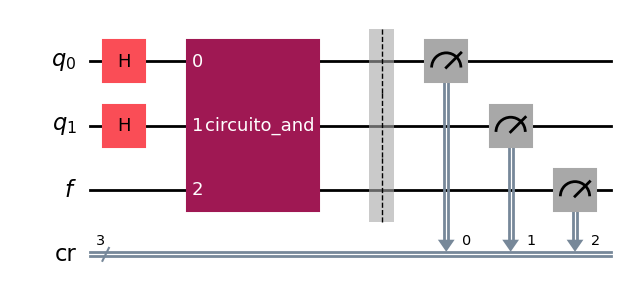

In [70]:
qr_q1q0 = QuantumRegister(2, name='q')  # dos qubits de entrada
qr_f = QuantumRegister(1, name='f')  # qbit de salida
cr = ClassicalRegister(3, name='cr')         # 3 bit clásico

circuitoPruebaAnd= QuantumCircuit(qr_q1q0, qr_f, cr)

#Generamos estado en superposición con todos las combinaciones de q1q0

circuitoPruebaAnd.h(0)
circuitoPruebaAnd.h(1)


circuitoPruebaAnd.append(circuito_and, [0,1,2])     # le agregamos al circuito la compuerta personalizada

circuitoPruebaAnd.barrier()
circuitoPruebaAnd.measure([0,1,2],[0,1,2])

circuitoPruebaAnd.draw('mpl')


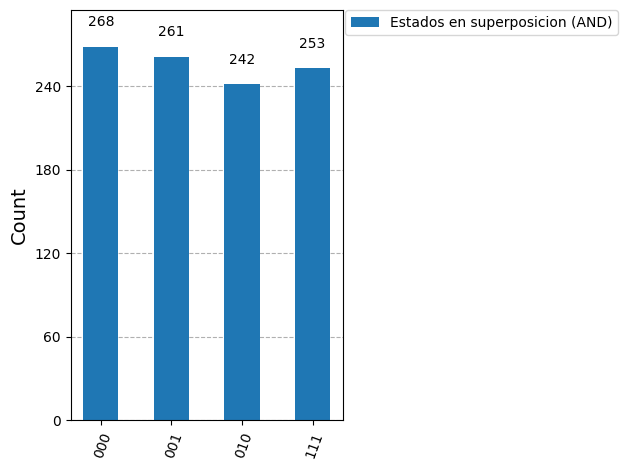

In [71]:
simulator_basic = BasicSimulator()

job = simulator_basic.run(circuitoPruebaAnd, shots=1024)
result = job.result()
result

counts = result.get_counts()
counts

plot_histogram(counts, legend=["Estados en superposicion (AND)"])

Al simular el circuito podemos ver que tiene todas las combinaciones de AND que colapsan en las graficas. Por lo tanto se puede 
ver que el paralelismo cuantico nos permite obtener todas las combinaciones posibles en una sola ejecución.

### OR

La tabla de verdad del circuito es:

$$
\begin{array}{|c|c|c|}
\hline
X0 & X1 & f = X0 \lor X1 \\
\hline
0 & 0 & 0 \\
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 1 \\
\hline
\end{array}
$$

Por lo que el circuito es:

In [55]:
def quantumOr(circ): ##La función Or
    circ.x(0)
    circ.x(1)
    circ.x(2)
    circ.ccx(0,1,2)
    circ.x(0)
    circ.x(1)
    return circ


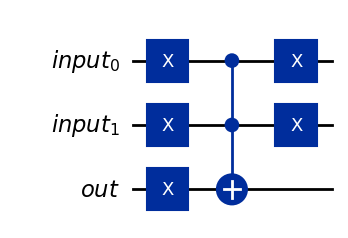

In [58]:
qr_in = QuantumRegister(2, name='input')  # dos qubits de entrada
qr_out = QuantumRegister(1, name='out')        # un qubit de salida



circuitoOr = quantumOr(QuantumCircuit(qr_in, qr_out))

circuitoOr.draw('mpl')

In [60]:
##Guardamos el circuito
matrix = Operator(circuitoOr)
circuito_or = UnitaryGate(matrix, 'circuito_or') #Compuerta personalizada

Creamos un estado en superposición

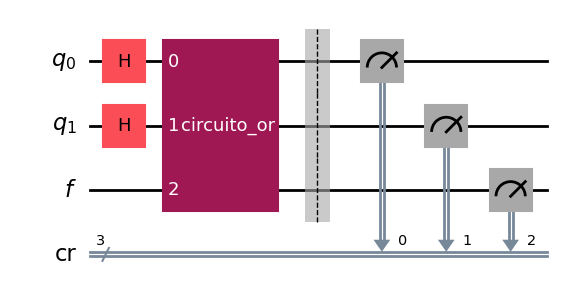

In [62]:
qr_q1q0 = QuantumRegister(2, name='q')  # dos qubits de entrada
qr_f = QuantumRegister(1, name='f')  # qbit de salida
cr = ClassicalRegister(3, name='cr')         # 3 bit clásico

circuitoPruebaOr= QuantumCircuit(qr_q1q0, qr_f, cr)

#Generamos estado en superposición con todos las combinaciones de q1q0

circuitoPruebaOr.h(0)
circuitoPruebaOr.h(1)


circuitoPruebaOr.append(circuito_or, [0,1,2])     # le agregamos al circuito la compuerta personalizada

circuitoPruebaOr.barrier()
circuitoPruebaOr.measure([0,1,2],[0,1,2])

circuitoPruebaOr.draw('mpl')


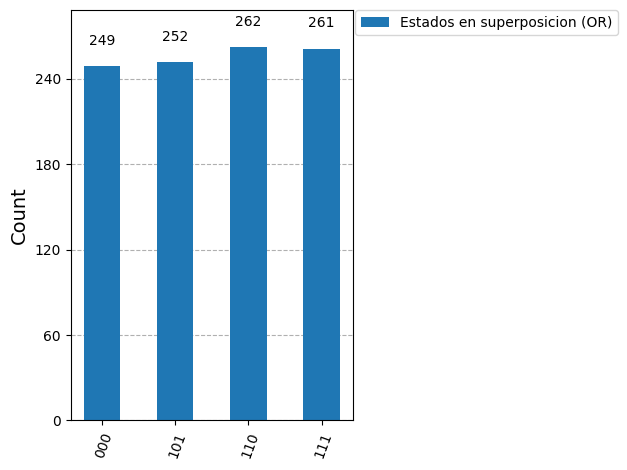

In [65]:
simulator_basic = BasicSimulator()

job = simulator_basic.run(circuitoPruebaOr, shots=1024)
result = job.result()
result

counts = result.get_counts()
counts

plot_histogram(counts, legend=["Estados en superposicion (OR)"])

Al simular el circuito podemos ver que tiene todas las combinaciones de OR que colapsan en las graficas. Por lo tanto se puede 
ver que el paralelismo cuantico nos permite obtener todas las combinaciones posibles en una sola ejecución.